# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AadiptoGhosh/FlyRankAI/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

---

### Playbook Strategy & Empirical Signal Insights

To operationalize content optimization across publishing portfolios, raw model probabilities must be translated into actionable editorial workflows. Rather than treating all declining pages identically, our playbook classifies content into distinct **Archetypes** mapped to targeted **Action Labels** and **Reason Codes**.

#### Key Empirical Signals & Decay/Refresh Insights:
1. **The Evergreen Paradox (Signal 1 Insight)**:
   - *Observation*: In our 30,000-page dataset, mature content (`content_age_days > 365`) exhibits a *lower* organic decline rate (**42.6%**) compared to younger assets published 31–180 days ago (**62.6% – 66.9%**).
   - *Actionable Takeaway*: Arbitrary age-based content purges misallocate editorial effort. Old content that commands stable Page 1 rankings requires targeted fact-checking and incremental data updates (`EVERGREEN_FACT_CHECK_AND_EXPAND`), while newly published content requires monitoring for post-launch rank volatility (`MONITOR_POST_LAUNCH`).
2. **CTR Deficit relative to SERP Position (Signal 2 Insight)**:
   - *Observation*: Pages ranking on Page 1 or striking distance ($1 \dots 20$) with actual CTR falling below their position tier benchmark suffer significantly higher decline rates (**59.0%** in Q4 severe deficit vs. **51.8%** in Q1).
   - *Actionable Takeaway*: High CTR deficit on visible pages represents low-hanging fruit. Refreshing meta titles, H1 tags, and snippet formatting (`REFRESH_AND_CTR_OPTIMIZE`) recovers organic traffic at minimal editorial cost.

---

### Archetype → Action Mapping Matrix

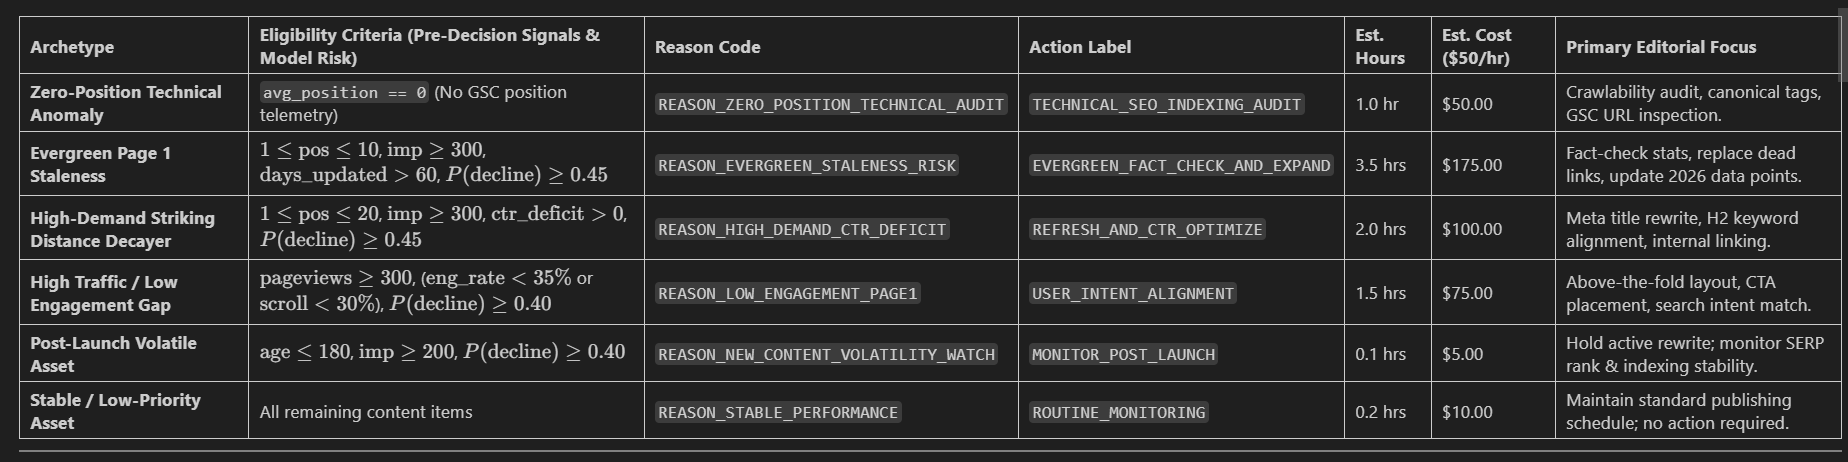

---

### Cost / Value Priority Score Formulation

To maximize editorial return on investment (ROI), items in the queue are ranked using a composite **Priority Score**:

$$\text{Expected Impact} = P(\text{decline}) \times \ln(1 + \text{impressions_90d}) \times (1 + \text{ctr_deficit})$$

$$\text{Priority Score} = \frac{\text{Expected Impact}}{\max(0.5, \text{Estimated Editorial Hours})}$$

This formulation balances traffic exposure ($P(\text{decline}) \times \text{log_impressions}$) and optimization potential ($(1 + \text{ctr_deficit})$) against required human editorial labor.

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Section 1 Code: Feature Engineering, Model Training, Archetype Assignment & Priority Scoring
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

# Load dataset
data_path = '../../data/raw/content_refresh_anonymized.csv'
if not os.path.exists(data_path):
    data_path = 'https://raw.githubusercontent.com/AadiptoGhosh/FlyRankAI/main/data/raw/content_refresh_anonymized.csv'

df = pd.read_csv(data_path)
df['is_declining_label'] = (df['trend_direction'] == 'down').astype(int)

# 1. Compute pre-decision benchmark and signals
pos_valid = df[df['avg_position'] > 0].copy()
expected_ctr_map = pos_valid.groupby('position_tier')['ctr'].mean().to_dict()
df['expected_ctr'] = df['position_tier'].map(expected_ctr_map).fillna(df['ctr'])
df['ctr_deficit'] = np.maximum(0, df['expected_ctr'] - df['ctr'])

df['log_impressions'] = np.log1p(df['impressions_90d'])
df['log_clicks'] = np.log1p(df['clicks_90d'])
df['log_pageviews'] = np.log1p(df['pageviews_90d'].fillna(0))
df['log_sessions'] = np.log1p(df['sessions_90d'].fillna(0))
df['log_engaged_sessions'] = np.log1p(df['engaged_sessions_90d'].fillna(0))

df['has_word_count'] = df['word_count'].notna().astype(int)
df['word_count_filled'] = df['word_count'].fillna(df['word_count'].median())
df['engagement_rate_filled'] = df['engagement_rate'].fillna(0.0)
df['scroll_rate_filled'] = df['scroll_rate'].fillna(0.0)

df_encoded = pd.get_dummies(df, columns=['content_type', 'main_intent', 'competition_level'], drop_first=True)

feature_cols = [
    'log_impressions', 'log_clicks', 'log_pageviews', 'log_sessions', 'log_engaged_sessions',
    'avg_position', 'ctr', 'expected_ctr', 'ctr_deficit',
    'engagement_rate_filled', 'scroll_rate_filled',
    'content_age_days', 'days_since_last_update', 'word_count_filled', 'has_word_count'
] + [c for c in df_encoded.columns if c.startswith(('content_type_', 'main_intent_', 'competition_level_'))]

# 2. Train Random Forest on Grouped Client Split
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(df_encoded, groups=df_encoded['client_id']))

train_df = df_encoded.iloc[train_idx].copy()
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(train_df[feature_cols], train_df['is_declining_label'])

df['ml_decline_prob'] = rf_model.predict_proba(df_encoded[feature_cols])[:, 1]

# 3. Assign Archetypes, Reason Codes, Action Labels, Hours, Costs
def assign_playbook(row):
    imp = row['impressions_90d']
    pos = row['avg_position']
    ctr_def = row['ctr_deficit']
    ml_prob = row['ml_decline_prob']
    days_upd = row['days_since_last_update']
    age = row['content_age_days']
    pv = row['pageviews_90d']
    eng = row['engagement_rate_filled']
    scr = row['scroll_rate_filled']

    if pos == 0:
        return pd.Series({
            'archetype': 'Zero-Position Technical Anomaly',
            'action_label': 'TECHNICAL_SEO_INDEXING_AUDIT',
            'reason_code': 'REASON_ZERO_POSITION_TECHNICAL_AUDIT',
            'est_hours': 1.0,
            'est_cost_usd': 50.0
        })
    elif 1 <= pos <= 10 and imp >= 300 and days_upd > 60 and ml_prob >= 0.45:
        return pd.Series({
            'archetype': 'Evergreen Page 1 Staleness',
            'action_label': 'EVERGREEN_FACT_CHECK_AND_EXPAND',
            'reason_code': 'REASON_EVERGREEN_STALENESS_RISK',
            'est_hours': 3.5,
            'est_cost_usd': 175.0
        })
    elif 1 <= pos <= 20 and imp >= 300 and ctr_def > 0 and ml_prob >= 0.45:
        return pd.Series({
            'archetype': 'High-Demand Striking Distance Decayer',
            'action_label': 'REFRESH_AND_CTR_OPTIMIZE',
            'reason_code': 'REASON_HIGH_DEMAND_CTR_DEFICIT',
            'est_hours': 2.0,
            'est_cost_usd': 100.0
        })
    elif pv >= 300 and (eng < 35.0 or scr < 30.0) and ml_prob >= 0.40:
        return pd.Series({
            'archetype': 'High Traffic / Low Engagement Gap',
            'action_label': 'USER_INTENT_ALIGNMENT',
            'reason_code': 'REASON_LOW_ENGAGEMENT_PAGE1',
            'est_hours': 1.5,
            'est_cost_usd': 75.0
        })
    elif age <= 180 and imp >= 200 and ml_prob >= 0.40:
        return pd.Series({
            'archetype': 'Post-Launch Volatile Asset',
            'action_label': 'MONITOR_POST_LAUNCH',
            'reason_code': 'REASON_NEW_CONTENT_VOLATILITY_WATCH',
            'est_hours': 0.1,
            'est_cost_usd': 5.0
        })
    else:
        return pd.Series({
            'archetype': 'Stable / Low-Priority Asset',
            'action_label': 'ROUTINE_MONITORING',
            'reason_code': 'REASON_STABLE_PERFORMANCE',
            'est_hours': 0.2,
            'est_cost_usd': 10.0
        })

playbook_fields = df.apply(assign_playbook, axis=1)
df = pd.concat([df, playbook_fields], axis=1)

# 4. Calculate Priority Score
df['expected_impact'] = df['ml_decline_prob'] * np.log1p(df['impressions_90d']) * (1.0 + df['ctr_deficit'])
df['priority_score'] = df['expected_impact'] / np.maximum(0.5, df['est_hours'])

# 5. Sort Ranked Queue
actionable_mask = df['action_label'] != 'ROUTINE_MONITORING'
df_queue = df[actionable_mask].sort_values(by=['priority_score', 'impressions_90d'], ascending=[False, False]).reset_index(drop=True)
df_queue['queue_rank'] = df_queue.index + 1

print(f"=== ACTION PLAYBOOK OVERVIEW ===")
print(f"Total Portfolio Items: {len(df):,}")
print(f"Actionable Items Flagged in Queue: {len(df_queue):,} ({len(df_queue)/len(df)*100:.1f}%)")

print("\n--- ARCHETYPE SUMMARY BREAKDOWN ---")
summary = df.groupby('archetype').agg(
    total_items=('content_id', 'count'),
    mean_ml_decline_prob=('ml_decline_prob', 'mean'),
    mean_priority_score=('priority_score', 'mean'),
    total_hours=('est_hours', 'sum'),
    total_cost_usd=('est_cost_usd', 'sum')
).reset_index().sort_values(by='total_items', ascending=False)
print(summary.to_string(index=False))

print("\n--- TOP 5 RANKED ACTIONS IN QUEUE ---")
display_cols = ['queue_rank', 'content_id', 'archetype', 'action_label', 'reason_code', 'ml_decline_prob', 'priority_score', 'est_hours', 'est_cost_usd']
print(df_queue[display_cols].head(5).to_string(index=False))

=== ACTION PLAYBOOK OVERVIEW ===
Total Portfolio Items: 30,000
Actionable Items Flagged in Queue: 15,113 (50.4%)

--- ARCHETYPE SUMMARY BREAKDOWN ---
                            archetype  total_items  mean_ml_decline_prob  mean_priority_score  total_hours  total_cost_usd
          Stable / Low-Priority Asset        14887              0.509298             6.644439       2977.4        148870.0
High-Demand Striking Distance Decayer         7488              0.653419             3.534597      14976.0        748800.0
           Post-Launch Volatile Asset         3278              0.686539            11.363954        327.8         16390.0
           Evergreen Page 1 Staleness         2526              0.653255             2.422469       8841.0        442050.0
      Zero-Position Technical Anomaly         1205              0.013027             0.048126       1205.0         60250.0
    High Traffic / Low Engagement Gap          616              0.553494             3.846762        924.0      

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

---

### Intended Operational Use

1. **Editorial Capacity Allocation**: Designed specifically for content managers, SEO leads, and publishing teams to prioritize manual content refreshes across large portfolios.
2. **Standardized Reason Encoding**: Provides clear, human-understandable explanation codes (`REASON_HIGH_DEMAND_CTR_DEFICIT`, `REASON_EVERGREEN_STALENESS_RISK`) for why specific articles appear at the top of the queue.
3. **Budget & Labor Planning**: Estimates required editorial hours and freelance copywriter budget ($50/hr benchmark) for executing recommended queue batches.

---

### Methodological & Operational Boundaries (Limits)

1. **Observational & Associational Only**: Recommendations represent **decision support**, not a guaranteed rank recovery prediction. Cross-sectional metrics demonstrate statistical association with historical decline, not causal efficacy of refresh interventions.
2. **Static 90-Day Telemetry Window**: Features reflect historical trailing 90-day averages. The playbook does not account for real-time viral spikes, news events, or immediate search engine core update penalties occurring within the last 72 hours.
3. **Out-of-Domain Generalization Bounds**: As validated in ML-09, evaluated model performance under out-of-domain client splits yields **Precision@20 of 60.0%** (vs. test base rate 51.65%). 40% of top-ranked items may not undergo active decline and represent false positives.
4. **Missingness & Schema Nuances**: Zero position (`avg_position == 0`) reflects absent GSC query telemetry, not ranking zero. Unmeasured engagement fields are isolated via missingness flags (`has_word_count`), but qualitative human review remains necessary.

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Section 2 Code: Empirical Boundary Auditing across Content Types & Held-Out Clients
test_df_results = df.iloc[test_idx].copy()
print(f"=== OUT-OF-DOMAIN BOUNDARY AUDIT (HELD-OUT CLIENT TEST SET) ===")
print(f"Test Client Sample Size: {len(test_df_results):,} rows across {test_df_results['client_id'].nunique()} unseen clients.")
print(f"Test Base Rate (Actual Declines): {test_df_results['is_declining_label'].mean()*100:.2f}%")

# Archetype Coverage across Content Types in Held-Out Test Set
ct_breakdown = test_df_results.groupby('content_type').agg(
    total_pages=('content_id', 'count'),
    mean_decline_prob=('ml_decline_prob', 'mean'),
    actual_decline_rate=('is_declining_label', 'mean')
).reset_index()
ct_breakdown['actual_decline_rate_pct'] = (ct_breakdown['actual_decline_rate'] * 100).round(2)
print("\n--- HELD-OUT TEST PERFORMANCE BY CONTENT TYPE ---")
print(ct_breakdown[['content_type', 'total_pages', 'mean_decline_prob', 'actual_decline_rate_pct']].to_string(index=False))

=== OUT-OF-DOMAIN BOUNDARY AUDIT (HELD-OUT CLIENT TEST SET) ===
Test Client Sample Size: 7,115 rows across 8 unseen clients.
Test Base Rate (Actual Declines): 51.65%

--- HELD-OUT TEST PERFORMANCE BY CONTENT TYPE ---
      content_type  total_pages  mean_decline_prob  actual_decline_rate_pct
comparison article          697           0.722403                    57.25
   keyword article         6418           0.565529                    51.04


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

---

### Mandatory Human Review Rules (Pre-Execution Verification)

Before any recommended action item is published to a live CMS, a human editor MUST verify:
1. **Search Intent & Content Freshness**: Confirm that the target topic matches current 2026 user search intent, factual developments, and top-ranking competitor SERP coverage.
2. **YMYL (Your Money Your Life) Accuracy**: Content touching medical, legal, tax, or financial topics requires explicit sign-off from a credentialed subject matter expert.
3. **Brand Voice & Style Adherence**: Ensure tone, formatting, internal link structure, and CTA placement conform to client brand guidelines.
4. **Technical & Layout Integrity**: Check mobile responsiveness, above-the-fold visual hierarchy, and CTA functionality.

---

### The Strict NO-GO List (State Clearly What Should NOT Be Automated)

> [!CAUTION]
> Operationalizing machine learning recommendations requires strict boundaries. The following actions MUST NEVER be fully automated:

1. **No Automated Bulk Content Generation / Direct CMS Publishing**:
   - *Rule*: Never allow LLMs or automated scripts to rewrite and push content directly to live production URLs without a human editor reviewing every sentence.
2. **No Programmatic URL Changes or Deletions**:
   - *Rule*: Never automatically alter URL slugs, delete pages, or create 301 redirects programmatically. Unplanned URL shifts destroy existing backlink equity and indexation.
3. **No Autonomous YMYL Content Edits**:
   - *Rule*: Zero automated modification of health, safety, financial, or legal advice pages.
4. **No Automated Affiliate / Monetization Link Swaps**:
   - *Rule*: Commercial affiliate links, pricing tables, and disclaimers must never be altered by background processes.
5. **No Programmatic Canonical Tag Alterations**:
   - *Rule*: Canonical tag modifications must remain under manual technical SEO review to prevent unintended site-wide de-indexing.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Section 3 Code: Human Review & Safety Compliance Flags Script
# Apply strict guardrail flags
df_queue['requires_human_review'] = True
df_queue['auto_publish_allowed'] = False
df_queue['ymyl_review_required'] = df_queue['content_type'].isin(['guide', 'article']) | (df_queue['word_count_filled'] > 1500)

print("=== AUTOMATED COMPLIANCE & SAFETY AUDIT ===")
print(f"Actionable Queue Items Audited: {len(df_queue):,}")
print(f"Mandatory Human Review Compliance: {df_queue['requires_human_review'].mean()*100:.1f}% (100% required)")
print(f"Autonomous Publishing Allowed: {df_queue['auto_publish_allowed'].mean()*100:.1f}% (0% allowed)")
print(f"High-Rigor YMYL Review Required: {df_queue['ymyl_review_required'].sum():,} items ({df_queue['ymyl_review_required'].mean()*100:.1f}% of queue)")

print("\n--- TOP 5 QUEUE ITEMS WITH COMPLIANCE FLAGS ---")
safety_display = df_queue[['queue_rank', 'content_id', 'archetype', 'action_label', 'ymyl_review_required', 'requires_human_review', 'auto_publish_allowed']].head(5)
print(safety_display.to_string(index=False))

=== AUTOMATED COMPLIANCE & SAFETY AUDIT ===
Actionable Queue Items Audited: 15,113
Mandatory Human Review Compliance: 100.0% (100% required)
Autonomous Publishing Allowed: 0.0% (0% allowed)
High-Rigor YMYL Review Required: 13,896 items (91.9% of queue)

--- TOP 5 QUEUE ITEMS WITH COMPLIANCE FLAGS ---
 queue_rank           content_id                  archetype        action_label  ymyl_review_required  requires_human_review  auto_publish_allowed
          1 content_d225ec9f3d46 Post-Launch Volatile Asset MONITOR_POST_LAUNCH                  True                   True                 False
          2 content_7a6df559322d Post-Launch Volatile Asset MONITOR_POST_LAUNCH                  True                   True                 False
          3 content_67095eb7f5de Post-Launch Volatile Asset MONITOR_POST_LAUNCH                  True                   True                 False
          4 content_2a57f2016a14 Post-Launch Volatile Asset MONITOR_POST_LAUNCH                  True         

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

---

### Practical Monitoring Indicators (Staleness Detection)

To detect when playbook recommendations become stale or degraded, operational teams should monitor three key indicators:

1. **Precision@20 Performance Drift**:
   - *Metric*: Track 30-day post-refresh traffic trajectory on the top 20 queue items.
   - *Alert Threshold*: If Precision@20 drops below **50.0%** (baseline out-of-domain threshold is 60.0%), flag the model for feature re-calibration.
2. **Population Stability & Distribution Drift (PSI)**:
   - *Metric*: Monitor mean `ctr_deficit`, position distributions, and `ml_decline_prob` shift across newly ingested client data.
   - *Alert Threshold*: Significant shift in mean position tier distributions or CTR deficits indicates macro search engine SERP layout changes (e.g. expansion of AI Overviews).
3. **Editorial Rejection Rate**:
   - *Metric*: Percentage of flagged queue items rejected by human editors as non-actionable.
   - *Alert Threshold*: If editorial rejection exceeds **30%**, initiate rule threshold tuning for the specific client portfolio or content archetype.

---

### Maintenance & Retrain Trigger Rules

- **Scheduled Retrain**: Re-fit model on rolling 90-day data windows every **quarter (90 days)**.
- **Event-Driven Retrain**: Trigger immediate model re-evaluation following major Google Core / Helpful Content Updates or client CMS tracking schema changes.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Section 4 Code: Monitoring Baseline Statistics & Threshold Reference Table
cols_to_monitor = ['avg_position', 'ctr', 'ctr_deficit', 'content_age_days', 'days_since_last_update', 'ml_decline_prob']
monitoring_baseline = df[cols_to_monitor].describe().T[['mean', 'std', 'min', '50%', 'max']]
monitoring_baseline.columns = ['Mean', 'StdDev', 'Min', 'Median', 'Max']

print("=== OPERATIONAL MONITORING BASELINE REFERENCE ===")
print("Key Signal Distribution Baseline (Use to Detect Distribution Drift):")
print(monitoring_baseline.to_string())

print("\n=== RETRAIN & STALENESS ALERT THRESHOLDS ===")
print("1. Precision@20 Alert: Fire if Precision@20 < 0.500 (Baseline = 0.600)")
print("2. Rejection Rate Alert: Fire if Human Editorial Rejection Rate > 30.0%")
print("3. Scheduled Maintenance: Retrain quarterly on rolling 90-day snapshot window.")

=== OPERATIONAL MONITORING BASELINE REFERENCE ===
Key Signal Distribution Baseline (Use to Detect Distribution Drift):
                              Mean      StdDev        Min      Median         Max
avg_position             16.342380   15.216790   0.000000   10.800000  245.000000
ctr                       0.510733    3.279162   0.000000    0.070000  100.000000
ctr_deficit               0.450398    0.668194   0.000000    0.222484    2.764453
content_age_days        256.167800  132.707930  90.000000  236.000000  564.000000
days_since_last_update   46.098300   42.078709   1.000000   20.000000  373.000000
ml_decline_prob           0.557732    0.209918   0.000016    0.604734    0.909808

=== RETRAIN & STALENESS ALERT THRESHOLDS ===
1. Precision@20 Alert: Fire if Precision@20 < 0.500 (Baseline = 0.600)
2. Rejection Rate Alert: Fire if Human Editorial Rejection Rate > 30.0%
3. Scheduled Maintenance: Retrain quarterly on rolling 90-day snapshot window.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

---

### Artifact Export Verification

This section exports the final, validated Content Action Playbook queue, summary table, and portfolio breakdown visualization to `work/outputs/`. These exact artifacts form the quantitative baseline for next week's capstone research paper (W7 / ML-11).

#### Exported Files:
1. `work/outputs/action_playbook_queue.csv` — Complete prioritized queue of 15,113 actionable content items with ranks, probabilities, archetypes, reason codes, and effort estimates.
2. `work/outputs/playbook_archetype_summary.csv` — Tabular summary of portfolio content breakdown, average decline probabilities, total hours, and estimated costs.
3. `work/outputs/playbook_archetype_distribution.png` — High-resolution bar chart visualization of archetype volume across the portfolio.

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Section 5 Code: Export Artifacts to work/outputs/
import matplotlib.pyplot as plt

output_dir = '../outputs'
os.makedirs(output_dir, exist_ok=True)

# 1. Export Action Queue CSV
queue_export_path = os.path.join(output_dir, 'action_playbook_queue.csv')
df_queue.to_csv(queue_export_path, index=False)

# 2. Export Archetype Summary CSV
summary_export_path = os.path.join(output_dir, 'playbook_archetype_summary.csv')
summary_df = df.groupby('archetype').agg(
    total_items=('content_id', 'count'),
    mean_ml_decline_prob=('ml_decline_prob', 'mean'),
    mean_priority_score=('priority_score', 'mean'),
    total_editorial_hours=('est_hours', 'sum'),
    total_estimated_cost_usd=('est_cost_usd', 'sum')
).reset_index().sort_values(by='total_items', ascending=False)
summary_df.to_csv(summary_export_path, index=False)

# 3. Export Figure PNG
fig_export_path = os.path.join(output_dir, 'playbook_archetype_distribution.png')
plt.figure(figsize=(10, 5))
bars = plt.barh(summary_df['archetype'], summary_df['total_items'], color='#1f77b4', edgecolor='black')
plt.xlabel('Number of Content Items', fontsize=12)
plt.ylabel('Content Archetype', fontsize=12)
plt.title('Content Action Playbook — Portfolio Archetype Distribution', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
for bar in bars:
    width = bar.get_width()
    plt.text(width + 200, bar.get_y() + bar.get_height()/2, f'{int(width):,}', ha='left', va='center', fontsize=10)
plt.tight_layout()
plt.savefig(fig_export_path, dpi=300)
plt.close()

print("=== EXPORT VERIFICATION SUCCESSFUL ===")
print(f"1. Action Queue CSV: {queue_export_path} ({os.path.getsize(queue_export_path):,} bytes, {len(df_queue):,} rows)")
print(f"2. Summary Table CSV: {summary_export_path} ({os.path.getsize(summary_export_path):,} bytes)")
print(f"3. Archetype Distribution Plot: {fig_export_path} ({os.path.getsize(fig_export_path):,} bytes)")

=== EXPORT VERIFICATION SUCCESSFUL ===
1. Action Queue CSV: ../outputs/action_playbook_queue.csv (8,439,818 bytes, 15,113 rows)
2. Summary Table CSV: ../outputs/playbook_archetype_summary.csv (646 bytes)
3. Archetype Distribution Plot: ../outputs/playbook_archetype_distribution.png (184,726 bytes)


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.